<a href="https://colab.research.google.com/github/makkergauri/uttarakhand-landslide-risk/blob/main/02_landslide_inventory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# %% Setup - Drive for the review results and the feature stack
from google.colab import drive
drive.mount('/content/drive')
!pip install -q rasterio matplotlib-scalebar

Mounted at /content/drive


In [2]:
# %% Load my review results and remove duplicate landslides
import glob, os
import numpy as np
import pandas as pd
import geopandas as gpd

base = "/content/drive/MyDrive/landslide_project"

# taking the newest export in case there are several copies
files = sorted(glob.glob(f"{base}/landslide_review_rudraprayag*.geojson"), key=os.path.getmtime)
review = gpd.read_file(files[-1]).to_crs("EPSG:32644")  # metres, same as the feature stack
print("File used:", files[-1])
print(review["decision"].value_counts())

# some "yes" patches are bits of the same landslide, so keeping only one point within 200 m
yes = review[review["decision"] == "yes"].reset_index(drop=True)
kept = []
for i, geom in enumerate(yes.geometry):
    if all(geom.distance(yes.geometry[k]) > 200 for k in kept):
        kept.append(i)
landslides = yes.loc[kept].copy()
print(len(yes), "yes points ->", len(landslides), "after removing duplicates")

File used: /content/drive/MyDrive/landslide_project/landslide_review_rudraprayag.geojson
decision
no        190
unsure     67
yes        42
Name: count, dtype: int64
42 yes points -> 38 after removing duplicates


In [3]:
# %% Random "no landslide" points in the same kind of terrain the landslides came from
import rasterio
from rasterio.plot import plotting_extent

with rasterio.open(f"{base}/rudraprayag_features.tif") as src:
    elev = src.read(1)
    lc = src.read(5)
    transform = src.transform
    extent = plotting_extent(src)

# same rules as the candidate search: below 3500 m, not snow/ice (70) or water (80)
# otherwise the model could "cheat" by learning that high peaks never have landslides
valid = (elev > 0) & (elev < 3500) & (lc != 70) & (lc != 80)
rows, cols = np.where(valid)

rng = np.random.default_rng(42)  # fixed seed so I get the same points every time
pick = rng.permutation(len(rows))[:5000]
xs, ys = rasterio.transform.xy(transform, rows[pick], cols[pick])
pool = gpd.GeoDataFrame(geometry=gpd.points_from_xy(xs, ys), crs="EPSG:32644")

# at least 500 m away from any landslide, one "no" point for every landslide (1:1)
dist = pool.geometry.apply(lambda p: landslides.distance(p).min())
stable = pool[dist > 500].head(len(landslides)).copy()
print(len(landslides), "landslides,", len(stable), "no-landslide points")

# saving both for step 3 (label 1 = landslide, 0 = no landslide)
landslides["label"] = 1
stable["label"] = 0
points = pd.concat([landslides[["geometry", "label"]], stable[["geometry", "label"]]], ignore_index=True)
points.to_file(f"{base}/training_points.geojson", driver="GeoJSON")
print("Saved training_points.geojson")

38 landslides, 38 no-landslide points
Saved training_points.geojson


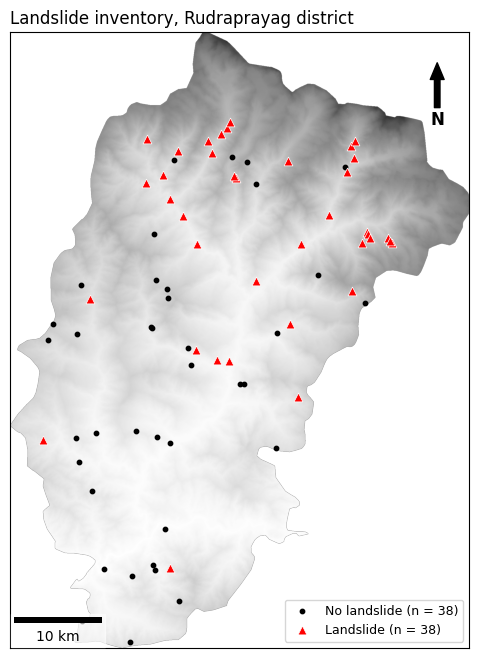

In [4]:
# %% Figure 3 - landslide inventory map
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar

fig, ax = plt.subplots(figsize=(7, 8))
ax.imshow(np.where(elev > 0, elev, np.nan), cmap="Greys", extent=extent, alpha=0.8)
stable.plot(ax=ax, color="black", markersize=10, label=f"No landslide (n = {len(stable)})")
landslides.plot(ax=ax, color="red", marker="^", markersize=40, edgecolor="white",
                linewidth=0.5, label=f"Landslide (n = {len(landslides)})")

ax.set_title("Landslide inventory, Rudraprayag district", loc="left")
ax.set_xticks([]); ax.set_yticks([])
ax.legend(loc="lower right", fontsize=9)
ax.add_artist(ScaleBar(1, location="lower left", box_alpha=0.6))
ax.annotate("N", xy=(0.93, 0.95), xytext=(0.93, 0.85), xycoords="axes fraction", ha="center",
            fontsize=12, fontweight="bold", arrowprops=dict(facecolor="black", width=4, headwidth=10))

os.makedirs(f"{base}/figures", exist_ok=True)
fig.savefig(f"{base}/figures/fig3_landslide_inventory.png", dpi=300, bbox_inches="tight")
fig.savefig(f"{base}/figures/fig3_landslide_inventory.pdf", bbox_inches="tight")
plt.show()

In [5]:
# quick sanity check - I want the real numbers for notes.md and the README
print("reviewed points in export:", len(review))
print(review["decision"].value_counts())
print("yes before dedupe:", len(yes))
print("landslides after 200 m dedupe:", len(landslides))
print("no-landslide points:", (points["label"] == 0).sum())
print("total training points:", len(points))

reviewed points in export: 299
decision
no        190
unsure     67
yes        42
Name: count, dtype: int64
yes before dedupe: 42
landslides after 200 m dedupe: 38
no-landslide points: 38
total training points: 76
